# RL Project — Highway-v0

**CentraleSupélec — Mention IA**

This notebook covers the **shared core task**:
1. A hand-implemented DQN agent trained on `highway-v0`
2. Training curves, behaviour analysis, and a failure-mode discussion

All experiments use the **instructor-provided shared config** so results are comparable across groups.

## 0 — Setup

In [2]:
import os
import copy
import random
import time
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym
import highway_env

os.environ["SDL_VIDEODRIVER"] = "dummy"

print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"Gym     : {gym.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Python  : 3.13.5
PyTorch : 2.10.0+cu130
Gym     : 1.2.3
Using device: cuda


## 1 — Shared Environment Configuration

The config below is fixed for all groups. Do not modify it for the core task — it defines the benchmark.

In [3]:
SHARED_CORE_ENV_ID = "highway-v0"

SHARED_CORE_CONFIG = {
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 10,
        "features": ["presence", "x", "y", "vx", "vy"],
        "absolute": False,
        "normalize": True,
        "clip": True,
        "see_behind": True,
        "observe_intentions": False,
    },
    "action": {
        "type": "DiscreteMetaAction",
        "target_speeds": [20, 25, 30],
    },
    "lanes_count": 4,
    "vehicles_count": 45,
    "controlled_vehicles": 1,
    "initial_lane_id": None,
    "duration": 30,
    "ego_spacing": 2,
    "vehicles_density": 1.0,
    "collision_reward": -1.5,
    "right_lane_reward": 0.0,
    "high_speed_reward": 0.7,
    "lane_change_reward": -0.02,
    "reward_speed_range": [22, 30],
    "normalize_reward": True,
    "offroad_terminal": True,
}

def make_env(config=None, render_mode=None):
    env = gym.make(SHARED_CORE_ENV_ID, render_mode=render_mode)
    if config:
        env.unwrapped.config.update(config)
    return env

env = make_env(SHARED_CORE_CONFIG)
obs, _ = env.reset()
print("Observation shape :", obs.shape)
print("Action space      :", env.action_space)
print("Flattened obs size:", obs.flatten().shape[0])

Observation shape : (10, 5)
Action space      : Discrete(5)
Flattened obs size: 50


## 2 — Double DQN Implementation

We implement the full double DQN algorithm based on the code found in [this repository](https://github.com/yahsiuhsieh/dqn-dense-traffic/blob/main/Highway/double_dqn.py). It is relativaly closed to the one used in the simple DQN implementation.

### 2.1 Replay Buffer

In [5]:
class Replay:
    def __init__(self, buffer_size, init_length, state_dim, action_dim, env):
        """
        A function to initialize the replay buffer.

        : param init_length: int, initial number of transitions to collect
        : param state_dim: int, size of the state space
        : param action_dim: int, size of the action space
        : param env: gym environment object
        """
        self.buffer_size = buffer_size
        self.init_length = init_length
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.env = env

        self._storage = []
        self._init_buffer(init_length)

    def _init_buffer(self, n):
        """
        Init buffer with n samples with state-transitions taken from random actions

        : param n: int, number of samples
        """
        state, _ = self.env.reset()  # Fix: gymnasium returns (obs, info)
        for _ in range(n):
            action = self.env.action_space.sample()
            state_next, reward, terminated, truncated, _ = self.env.step(action)  # Fix: gymnasium 5-value unpack
            done = terminated or truncated
            exp = {
                "state": state,
                "action": action,
                "reward": reward,
                "state_next": state_next,
                "done": done,
            }
            self._storage.append(exp)
            state = state_next

            if done:
                state, _ = self.env.reset()  # Fix: unpack (obs, info)
                done = False

    def buffer_add(self, exp):
        """
        A function to add a dictionary to the buffer

        : param exp: a dictionary consisting of state, action, reward , next state and done flag
        """
        self._storage.append(exp)
        if len(self._storage) > self.buffer_size:
            self._storage.pop(0)

    def buffer_sample(self, N):
        """
        A function to sample N points from the buffer

        : param N: int, number of samples to obtain from the buffer
        """
        return random.sample(self._storage, N)


### 2.2 Neural Network

A small MLP with two hidden layers. The input is the flattened kinematic observation (50 features), and the output has one Q-value per discrete action.

In [6]:
class Net(nn.Module):
    def __init__(self, state_dim, action_dim):
        """
        Initialize the network

        : param state_dim: int, size of state space
        : param action_dim: int, size of action space
        """
        super(Net, self).__init__()

        hidden_nodes1 = 512
        hidden_nodes2 = 256
        self.fc1 = nn.Linear(state_dim, hidden_nodes1)
        self.fc2 = nn.Linear(hidden_nodes1, hidden_nodes2)
        self.fc3 = nn.Linear(hidden_nodes2, action_dim)

    def forward(self, state):
        """
        Define the forward pass of the actor

        : param state: ndarray, the state of the environment
        """
        x = state
        # print(x.shape)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        out = self.fc3(x)
        return out

### 2.3 Double DQN Agent

Key design choices:
- **Batch size**: 5 (small batch for frequent updates, faster but noisier gradients)
- **Replay buffer capacity**: 1 000 transitions
- **Target network sync**: every 100 steps
- **ε-greedy policy**: fixed ε = 0.9 during training (high exploitation, limited exploration)
- **Optimizer**: Adam with learning rate 0.001
- **Discount factor (γ)**: 0.99

In [7]:
class DOUBLEDQN(nn.Module):
    def __init__(
        self,
        env,
        state_dim,
        action_dim,
        lr=0.001,
        gamma=0.99,
        batch_size=5,
        timestamp="",
    ):
        """
        : param env: object, a gym environment
        : param state_dim: int, size of state space
        : param action_dim: int, size of action space
        : param lr: float, learning rate
        : param gamma: float, discount factor
        : param batch_size: int, batch size for training
        """
        super(DOUBLEDQN, self).__init__()

        self.env = env
        self.env.reset()
        self.timestamp = timestamp

        self.test_env = copy.deepcopy(env)  # for evaluation purpose
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.learn_step_counter = 0

        self.target_net = Net(self.state_dim, self.action_dim).to(device)
        self.estimate_net = Net(self.state_dim, self.action_dim).to(device)
        self.ReplayBuffer = Replay(1000, 100, self.state_dim, self.action_dim, env)

        self.optimizer = torch.optim.Adam(self.estimate_net.parameters(), lr=lr)

    def update_target_networks(self):
        """
        A function to update the target networks
        """
        self.target_net.load_state_dict(self.estimate_net.state_dict())

    def choose_action(self, state, epsilon=0.9):
        """
        Select action using epsilon greedy method

        : param state: ndarray, the state of the environment
        : param epsilon: float, between 0 and 1
        : return: ndarray, chosen action
        """
        state = torch.FloatTensor(state).to(device).reshape(-1)  # get a 1D array
        if np.random.randn() <= epsilon:
            action_value = self.estimate_net(state)
            action = torch.argmax(action_value).item()
        else:
            action = np.random.randint(0, self.action_dim)
        return action

    def train(self, num_epochs):
        """
        Train the policy for the given number of iterations

        :param num_epochs: int, number of epochs to train the policy for
        """
        count_list = []
        loss_list = []
        total_reward_list = []
        avg_reward_list = []
        epoch_reward = 0
        epochs_since_log = 0  # Fix: track epochs accumulated for correct averaging

        for epoch in range(int(num_epochs)):
            print(f"{epoch+1}/{num_epochs}")
            done = False
            state, _ = self.env.reset()  # Fix: gymnasium returns (obs, info)
            avg_loss = 0
            step = 0
            while not done:
                step += 1
                action = self.choose_action(state)
                state_next, reward, terminated, truncated, _ = self.env.step(action)  # Fix: gymnasium 5-value unpack
                done = terminated or truncated
                # store experience to replay memory
                exp = {
                    "state": state,
                    "action": action,
                    "reward": reward,
                    "state_next": state_next,
                    "done": done,
                }
                self.ReplayBuffer.buffer_add(exp)
                state = state_next

                # sample random batch from replay memory
                exp_batch = self.ReplayBuffer.buffer_sample(self.batch_size)

                # extract batch data
                state_batch = torch.FloatTensor([exp["state"] for exp in exp_batch]).to(
                    device
                )
                action_batch = torch.LongTensor(
                    [exp["action"] for exp in exp_batch]
                ).to(device)
                reward_batch = torch.FloatTensor(
                    [exp["reward"] for exp in exp_batch]
                ).to(device)
                state_next_batch = torch.FloatTensor(
                    [exp["state_next"] for exp in exp_batch]
                ).to(device)
                done_batch = torch.FloatTensor(
                    [1 - exp["done"] for exp in exp_batch]
                ).to(device)

                # reshape
                state_batch = state_batch.reshape(self.batch_size, -1)
                action_batch = action_batch.reshape(self.batch_size, -1)
                reward_batch = reward_batch.reshape(self.batch_size, -1)
                state_next_batch = state_next_batch.reshape(self.batch_size, -1)
                done_batch = done_batch.reshape(self.batch_size, -1)

                # get estimate Q value
                estimate_Q = self.estimate_net(state_batch).gather(1, action_batch)

                # get target Q value
                max_action_idx = self.estimate_net(state_next_batch).detach().argmax(1)
                target_Q = reward_batch + done_batch * self.gamma * self.target_net(
                    state_next_batch
                ).gather(1, max_action_idx.unsqueeze(1))

                # compute mse loss
                loss = F.mse_loss(estimate_Q, target_Q)
                avg_loss += loss.item()

                # update network
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                # update target network
                if self.learn_step_counter % 100 == 0:
                    self.target_net.load_state_dict(self.estimate_net.state_dict())
                self.learn_step_counter += 1

            reward, count = self.eval()
            epoch_reward += reward
            epochs_since_log += 1  # Fix: increment counter each epoch

            # save
            period = 40
            if epoch % period == 0:
                # log
                avg_loss /= step
                # Fix: divide by actual epochs accumulated, not fixed period
                epoch_reward /= max(epochs_since_log, 1)
                avg_reward_list.append(epoch_reward)
                loss_list.append(avg_loss)

                print(
                    "\nepoch: [{}/{}], \tavg loss: {:.4f}, \tavg reward: {:.3f}, \tsteps: {}".format(
                        epoch + 1, num_epochs, avg_loss, epoch_reward, count
                    )
                )

                epoch_reward = 0
                epochs_since_log = 0  # Fix: reset counter after logging
                # create a new directory for saving
                try:
                    os.makedirs(self.timestamp)
                except OSError:
                    pass
                np.save(self.timestamp + "/double_dqn_loss.npy", loss_list)
                np.save(self.timestamp + "/double_dqn_avg_reward.npy", avg_reward_list)
                torch.save(
                    self.estimate_net.state_dict(), self.timestamp + "/double_dqn.pkl"
                )

        self.env.close()
        return loss_list, avg_reward_list

    def eval(self):
        """
        Evaluate the policy
        """
        count = 0
        total_reward = 0
        done = False
        state, _ = self.test_env.reset()  # Fix: gymnasium returns (obs, info)

        while not done:
            action = self.choose_action(state, epsilon=1)
            state_next, reward, terminated, truncated, _ = self.test_env.step(action)  # Fix: gymnasium 5-value unpack
            done = terminated or truncated
            total_reward += reward
            count += 1
            state = state_next

        return total_reward, count


## 3 — Training the DQN

We train for a fixed budget of episodes and log the episode reward plus the TD loss.

In [6]:
# timestamp for saving
named_tuple = time.localtime()
time_string = time.strftime(
    "%m%d_%H_%M", named_tuple
)

# Instatante the double DQN agent
double_dqn_object = DOUBLEDQN(
    env,
    state_dim=50,
    action_dim=5,
    lr=0.001,
    gamma=0.99,
    batch_size=64,
    timestamp=time_string,
)

# Train the policy
iterations = 400
avg_loss, avg_reward_list = double_dqn_object.train(iterations)


1/400


C:\Users\flori\AppData\Local\Temp\ipykernel_19388\1059200421.py:100: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  state_batch = torch.FloatTensor([exp["state"] for exp in exp_batch]).to(



epoch: [1/400], 	avg loss: 0.4604, 	avg reward: 3.959, 	steps: 5
2/400
3/400
4/400
5/400
6/400
7/400
8/400
9/400
10/400
11/400
12/400
13/400
14/400
15/400
16/400
17/400
18/400
19/400
20/400
21/400
22/400
23/400
24/400
25/400
26/400
27/400
28/400
29/400
30/400
31/400
32/400
33/400
34/400
35/400
36/400
37/400
38/400
39/400
40/400
41/400

epoch: [41/400], 	avg loss: 0.5747, 	avg reward: 10.164, 	steps: 12
42/400
43/400
44/400
45/400
46/400
47/400
48/400
49/400
50/400
51/400
52/400
53/400
54/400
55/400
56/400
57/400
58/400
59/400
60/400
61/400
62/400
63/400
64/400
65/400
66/400
67/400
68/400
69/400
70/400
71/400
72/400
73/400
74/400
75/400
76/400
77/400
78/400
79/400
80/400
81/400

epoch: [81/400], 	avg loss: 1.3625, 	avg reward: 12.363, 	steps: 20
82/400
83/400
84/400
85/400
86/400
87/400
88/400
89/400
90/400
91/400
92/400
93/400
94/400
95/400
96/400
97/400
98/400
99/400
100/400
101/400
102/400
103/400
104/400
105/400
106/400
107/400
108/400
109/400
110/400
111/400
112/400
113/400
114/40

### 3.1 Saving loss and reward loss

In [7]:
np.save(time_string + "/double_dqn_loss.npy", avg_loss)
np.save(time_string + "/double_dqn_avg_reward.npy", avg_reward_list)

### 3.2 Saving Network

In [8]:
# save the dqn network
torch.save(
    double_dqn_object.estimate_net.state_dict(), time_string + "/double_dqn.pkl"
)

## 4. Visualisation

In [8]:
# Load the saved model
time_string = "0327_16_17"
load_path = time_string + "/double_dqn.pkl"

loaded_net = Net(state_dim=50, action_dim=5).to(device)
loaded_net.load_state_dict(torch.load(load_path, map_location=device))
loaded_net.eval()

print(f"Model loaded from: {load_path}")

Model loaded from: 0327_16_17/double_dqn.pkl


### 4.1 Training curves

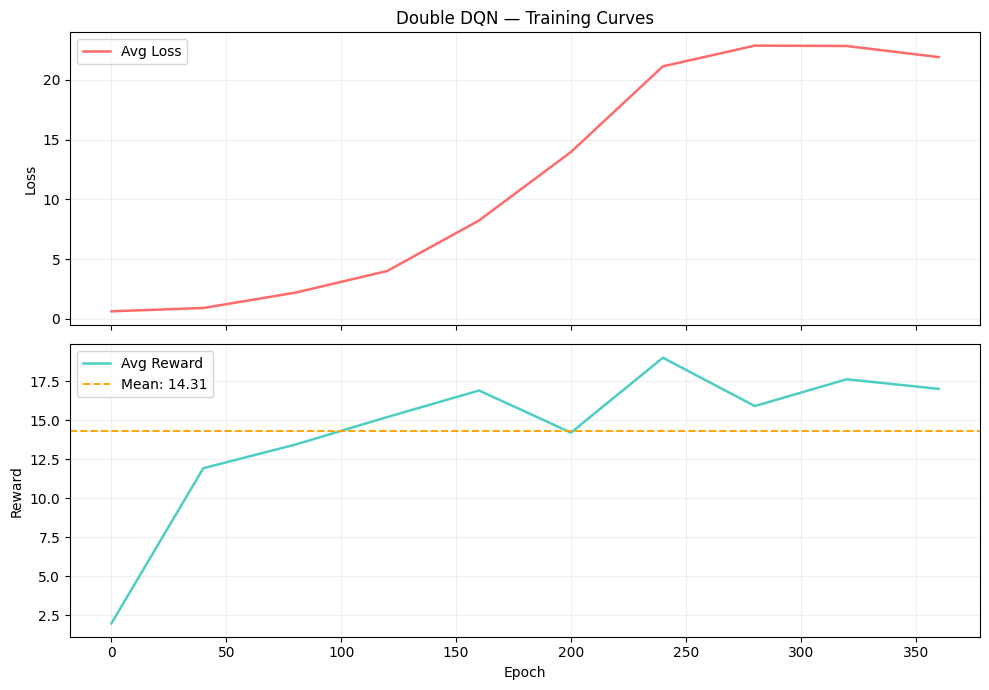

In [9]:
avg_loss = np.load(time_string + "/double_dqn_loss.npy")
avg_reward = np.load(time_string + "/double_dqn_avg_reward.npy")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.plot([40*k for k in range(10)], avg_loss, color='#ff6b6b', linewidth=1.8, label='Avg Loss')
ax1.set_ylabel('Loss')
ax1.set_title('Double DQN — Training Curves')
ax1.legend()
ax1.grid(alpha=0.2)

ax2.plot([40*k for k in range(10)], avg_reward, color='#4ecdc4', linewidth=1.8, label='Avg Reward')
ax2.axhline(np.mean(avg_reward), color='orange', linestyle='--', linewidth=1.4, label=f'Mean: {np.mean(avg_reward):.2f}')
ax2.set_ylabel('Reward')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 4.2 Untrained vs Trained

In [11]:
ACTION_LABELS = {0: "LANE_LEFT", 1: "IDLE", 2: "LANE_RIGHT", 3: "FASTER", 4: "SLOWER"}

def make_env(config=None, render_mode="rgb_array"):
    env = gym.make(SHARED_CORE_ENV_ID, render_mode=render_mode)
    if config:
        env.unwrapped.config.update(config)
    return env

def run_episode(net, config, seed=42, epsilon=0.0):
    """Roll out one episode and collect frames, actions and rewards."""
    env = make_env(config, render_mode="rgb_array")
    env.reset(seed=seed)
    env.step(env.action_space.sample())      # warm up renderer
    obs, _ = env.reset(seed=seed)

    frames, actions, rewards = [], [], []
    done = False

    while not done:
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            state_t = torch.FloatTensor(obs).to(device).reshape(-1)
            with torch.no_grad():
                action = net(state_t.unsqueeze(0)).argmax(dim=1).item()

        obs, r, terminated, truncated, _ = env.step(action)
        frame = env.render()
        if frame is not None:
            frames.append(frame)
            actions.append(action)
            rewards.append(r)
        done = terminated or truncated

    env.close()
    return frames, actions, rewards, terminated


In [12]:
print("Running UNTRAINED episode (random weights)...")
untrained_net = Net(state_dim=50, action_dim=5).to(device)
untrained_net.eval()

SHARED_CORE_CONFIG["duration"] = 30
SHARED_CORE_CONFIG["vehicles_density"] = 1.0

frames_before, actions_before, rewards_before, crashed_before = run_episode(
    untrained_net, SHARED_CORE_CONFIG, seed=None, epsilon=1.0
)
print(f"  Steps: {len(frames_before)} | Total reward: {sum(rewards_before):.3f} | "
      f"Ended by: {'CRASH' if crashed_before else 'TIMEOUT'}")

print("\nRunning TRAINED episode...")
frames_after, actions_after, rewards_after, crashed_after = run_episode(
    loaded_net, SHARED_CORE_CONFIG, seed=None, epsilon=0.0
)
print(f"  Steps: {len(frames_after)} | Total reward: {sum(rewards_after):.3f} | "
      f"Ended by: {'CRASH' if crashed_after else 'TIMEOUT'}")


Running UNTRAINED episode (random weights)...
  Steps: 7 | Total reward: 6.049 | Ended by: CRASH

Running TRAINED episode...
  Steps: 28 | Total reward: 20.487 | Ended by: CRASH


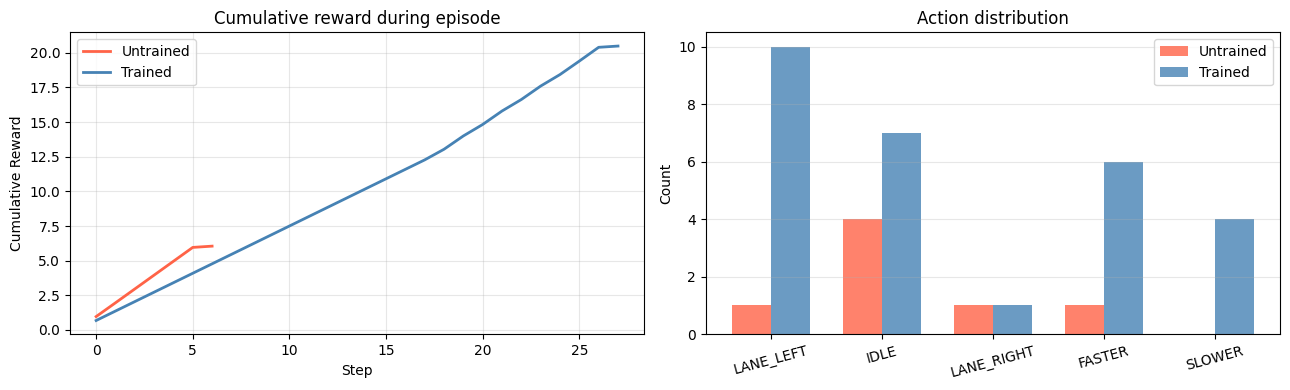

                        Untrained      Trained
----------------------------------------------
Total reward                6.049       20.487
Steps survived                  7           28
Crashed                       YES          YES
Mean step reward            0.864        0.732


In [13]:
N_ACTIONS = 5
n_act = N_ACTIONS
labels = [ACTION_LABELS.get(i, str(i)) for i in range(n_act)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Cumulative reward
ax = axes[0]
ax.plot(np.cumsum(rewards_before), color='tomato',    lw=2, label='Untrained')
ax.plot(np.cumsum(rewards_after),  color='steelblue', lw=2, label='Trained')
ax.set_xlabel('Step')
ax.set_ylabel('Cumulative Reward')
ax.set_title('Cumulative reward during episode')
ax.legend()
ax.grid(alpha=0.3)

# Action distribution
ax = axes[1]
x = np.arange(n_act)
w = 0.35
counts_before = np.bincount(actions_before, minlength=n_act)
counts_after  = np.bincount(actions_after,  minlength=n_act)
ax.bar(x - w/2, counts_before, w, color='tomato',    alpha=0.8, label='Untrained')
ax.bar(x + w/2, counts_after,  w, color='steelblue', alpha=0.8, label='Trained')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('Count')
ax.set_title('Action distribution')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(time_string + '/before_after_comparison.png', dpi=120)
plt.show()

# Summary table
print(f"{'':20} {'Untrained':>12} {'Trained':>12}")
print("-" * 46)
print(f"{'Total reward':<20} {sum(rewards_before):>12.3f} {sum(rewards_after):>12.3f}")
print(f"{'Steps survived':<20} {len(frames_before):>12d} {len(frames_after):>12d}")
print(f"{'Crashed':<20} {'YES' if crashed_before else 'NO':>12} {'YES' if crashed_after else 'NO':>12}")
print(f"{'Mean step reward':<20} {np.mean(rewards_before):>12.3f} {np.mean(rewards_after):>12.3f}")
